# 👋 Welcome to the introduction tutorial

In this tutorial, we will guide you, while using *puncc*, throughout the process of uncertainty quantification in a regression tasks. By the end of this notebook, you will be able to wrap your own models into conformal predictors and analyze their performance.

In addition, we will provide a guide on how to use conformal prediction for anomaly detection. Let's get started !

**Table of contents**

- [📈 Conformal Regression](#cr)
    - [💾 Diabetes Dataset](#cr-data)
    - [🔮 Predicton Model](#cr-pm)
    - [⚙️ Conformal Prediction](#cr-cp)

**Links**
- [<img src="https://github.githubassets.com/images/icons/emoji/octocat.png" width=20> Github](https://github.com/deel-ai/puncc)
- [📘 Documentation](https://deel-ai.github.io/puncc/index.html)

## 🛠️ Backend Configuration

**Puncc** supports various data types and model types.  
For this introductory notebook, we set the backend to NumPy.

In [1]:
from deel.puncc.config import set_backend
set_backend("tensorflow")

We set default backend dtype to float64 :

In [2]:
from deel.puncc._keras import backend
backend.set_floatx('float64')

2026-03-23 18:31:09.518293: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-23 18:31:09.600026: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 📈 Conformal Regression  <a class="anchor" id="cr"></a>

Let’s consider a simple regression problem on diabetes data provided in Scikit-learn. We want to evaluate the uncertainty associated with the prediction using inductive (or split) conformal prediction.

### 💾 Diabetes Dataset <a class="anchor" id="cr-data"></a>

The dataset contains information about 442 diabetes patients. The goal is predict from physiological variables a quantitative measure of disease progression in one year.
- There are ten standardized features corresponding to the age, sex, body mass index, average blood pressure, and six blood serum measurements. 
- The target is the measure of diabetes progression during one year for each patient.

For more information, check the official [documentation](https://www4.stat.ncsu.edu/~boos/var.select/diabetes.html).

In [3]:
from sklearn import datasets
# Load the diabetes dataset
import tensorflow as tf
diabetes_X, diabetes_y = datasets.load_diabetes(return_X_y=True)

# Convert to torch
diabetes_X = tf.convert_to_tensor(diabetes_X)
diabetes_y = tf.convert_to_tensor(diabetes_y)

print(f"Features shape: {diabetes_X.shape}")
print(f"Target's shape: {diabetes_y.shape}")

Features shape: (442, 10)
Target's shape: (442,)


2026-03-23 18:31:14.124217: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


From all the features, we want our model to capture only the link between body mass index and the evolution of the disease. 

In [4]:
# Use only BMI feature
diabetes_X = tf.expand_dims(diabetes_X[:, 2], 1)
diabetes_y = tf.expand_dims(diabetes_y, 1)

By construction, data are independent and identically distributed (i.i.d).

Great, we fullfill the prerequisites to apply conformal prediction 👏 !

The next step is spliting the data into three subsets:

* Fit subset ${\cal D_{fit}}$ to train the model.
* Calibration subset ${\cal D_{calib}}$ on which nonconformity scores are
  computed.
* Test subset ${\cal D_{test}}$ on which the prediction intervals are
  estimated.

---
**NOTE**

   Rigorously, for the probabilistic guarantee to hold, the calibration subset
   needs to be resampled for each new example in the test set.

---


The following code implements the aforementioned steps:

In [5]:
# Split the data into training/testing sets
X_train = diabetes_X[:-100]
X_test = diabetes_X[-100:]

# Split the targets into training/testing sets
y_train = diabetes_y[:-100]
y_test = diabetes_y[-100:]

# Split fit and calibration data
X_fit, X_calib = X_train[:-100], X_train[-100:]
y_fit, y_calib = y_train[:-100], y_train[-100:]

### 🔮 Prediction Model <a class="anchor" id="cr-pm"></a>

We consider a simple linear regression model from
[scikit-learn regression module](https://scikit-learn.org/stable/modules/linear_model.html),
to be trained later on ${\cal D_{fit}}$:

In [6]:
class LinearRegression(tf.keras.Model):
    def __init__(self, n_features):
        super().__init__()
        self.w = tf.Variable(
            tf.zeros((n_features, 1), dtype=tf.float64),
            trainable=True,
            name="weight"
        )
        self.b = tf.Variable(
            tf.zeros((1,), dtype=tf.float64),
            trainable=True,
            name="bias"
        )

    def call(self, X):
        return tf.matmul(X, self.w) + self.b

    def fit(self, X, y):
        ones = tf.ones((tf.shape(X)[0], 1), dtype=X.dtype)
        X_aug = tf.concat([ones, X], axis=1)

        beta = tf.linalg.lstsq(X_aug, y, fast=True)
        self.b.assign(beta[0, :])
        self.w.assign(beta[1:, :])
        
        
        return self
    
# Create linear regression model
lin_reg_predictor = LinearRegression(n_features=1)


### ⚙️ Conformal Prediction <a class="anchor" id="cr-cp"></a>

For this example, the prediction intervals are obtained throught the split
conformal prediction method provided by the class
`deel.puncc.regression.SplitCP`. Other methods are presented
in the [documentation](https://deel-ai.github.io/puncc/regression.html).

The library provides several metrics in `deel.puncc.metrics` to evaluate the conformalization procedure. Below, we compute the average empirical coverage and the average empirical width of the prediction intervals on the test examples:

In [7]:
from deel.puncc.regression import SplitCP

# Coverage target is 1-alpha = 90%
alpha=.1

# Instanciate the split cp wrapper around the linear predictor.
split_cp = SplitCP(lin_reg_predictor)

# Train model (if argument `is_train` is False) on the fitting dataset and
# compute the residuals on the calibration dataset. 
split_cp.fit(X_fit, y_fit)
split_cp.calibrate(X_calib, y_calib)

## Alternatively, we can randomly select the fit/calib subsets as below 
# split_cp.fit(X=X_train, y=y_train, fit_ratio=.8)

# The `predict` returns the output of the linear model `y_pred` and
# the calibrated interval [`y_pred_lower`, `y_pred_upper`].
y_pred, y_set= split_cp.predict(X_test, alpha=alpha)
y_pred_lower, y_pred_upper = y_set[..., 0], y_set[..., 1]

2026-03-23 18:31:16.695443: E tensorflow/core/util/util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


In [8]:
from deel.puncc import metrics

coverage = metrics.regression_mean_coverage(y_test, y_pred_lower, y_pred_upper)
width = metrics.regression_sharpness(y_pred_lower=y_pred_lower,
                                    y_pred_upper=y_pred_upper)
print(f"Marginal coverage: {coverage:.2f}")
print(f"Average width: {width:.2f}")

Marginal coverage: 0.95
Average width: 211.38


In addition, puncc provides plotting tools in `deel.puncc.plotting` to visualize the prediction intervals and whether or not the observations are covered:

(100, 1) (100, 1) (100, 1) (100, 1) (100, 1)


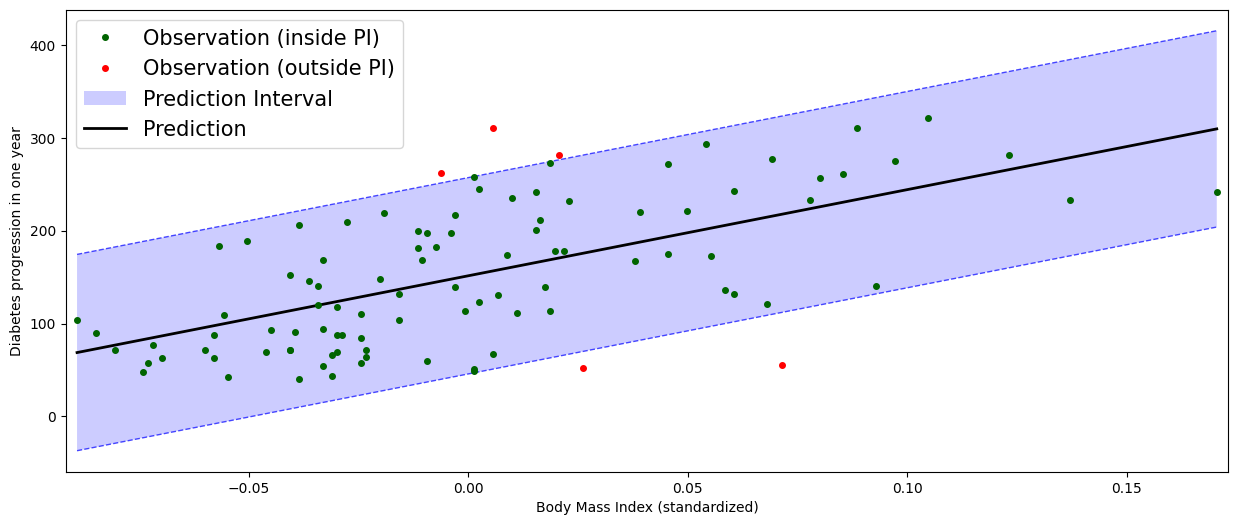

In [9]:
from deel.puncc.plotting import plot_prediction_intervals

# Figure of the prediction bands

print(X_test.shape, y_test.shape, y_pred.shape, y_pred_lower.shape, y_pred_upper.shape)

ax = plot_prediction_intervals(
        X = tf.keras.ops.convert_to_numpy(X_test).squeeze(),
        y_true=tf.keras.ops.convert_to_numpy(y_test).squeeze(),
        y_pred=tf.keras.ops.convert_to_numpy(y_pred).squeeze(),
        y_pred_lower=tf.keras.ops.convert_to_numpy(y_pred_lower).squeeze(),
        y_pred_upper=tf.keras.ops.convert_to_numpy(y_pred_upper).squeeze(),
        loc="upper left")

_ = ax.set_xlabel("Body Mass Index (standardized)")
_ = ax.set_ylabel("Diabetes progression in one year")